### Univariate Gaussian Distribution
We start with the simplest and most common univariate Gaussian distribution, whose probability density function is:

$$p(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right) \qquad (1)$$

Where $\mu$ and $\sigma$ represent the mean and variance respectively. The curve of this probability density function is the familiar bell-shaped curve; the mean and variance uniquely determine the shape of the curve.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_pdf_1d(x, mu=0.0, sigma=1.0):
    """
    一元高斯分布 PDF
    """
    x = np.asarray(x, dtype=float)
    coef = 1.0 / np.sqrt(2 * np.pi * sigma**2)
    exponent = - (x - mu)**2 / (2 * sigma**2)
    return coef * np.exp(exponent)

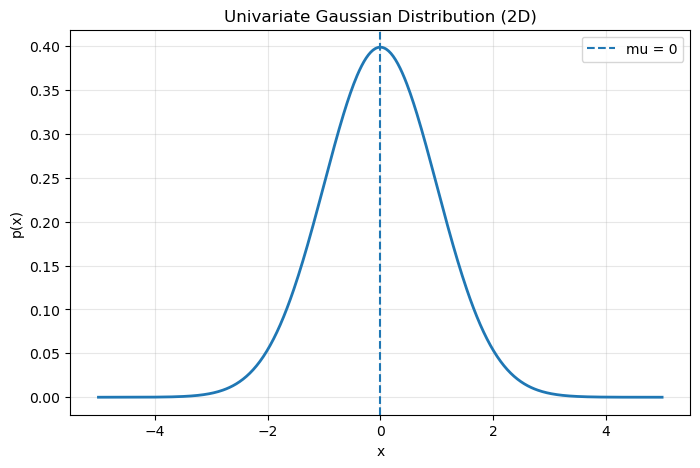

In [ ]:
x = np.linspace(-5, 5, 500)
y = gaussian_pdf_1d(x, mu=0, sigma=1)

plt.figure(figsize=(8, 5))
plt.plot(x, y, linewidth=2)
plt.axvline(0, linestyle="--", label="mu = 0")
plt.title("Univariate Gaussian Distribution (2D)")
plt.xlabel("x")
plt.ylabel("p(x)") # 概率密度 p(x), 某个区间内的概率 = 曲线下面的面积
plt.legend()
plt.grid(alpha=0.3)
plt.show()

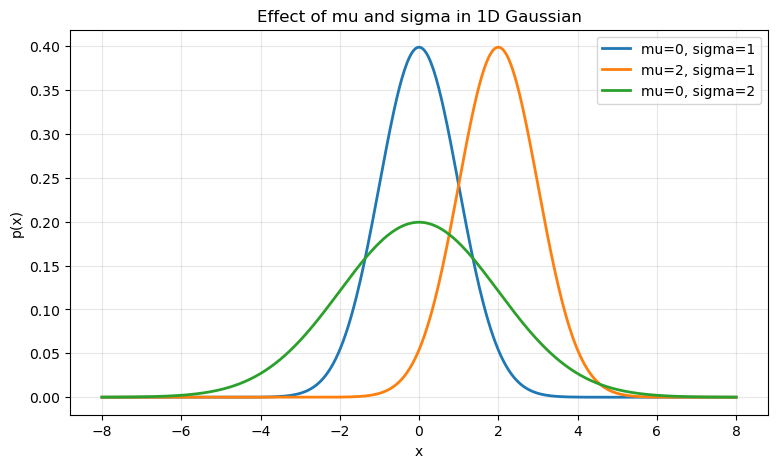

In [4]:
x = np.linspace(-8, 8, 500)

plt.figure(figsize=(9, 5))
plt.plot(x, gaussian_pdf_1d(x, mu=0, sigma=1), label="mu=0, sigma=1", linewidth=2)
plt.plot(x, gaussian_pdf_1d(x, mu=2, sigma=1), label="mu=2, sigma=1", linewidth=2)
plt.plot(x, gaussian_pdf_1d(x, mu=0, sigma=2), label="mu=0, sigma=2", linewidth=2)

plt.title("Effect of mu and sigma in 1D Gaussian")
plt.xlabel("x")
plt.ylabel("p(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

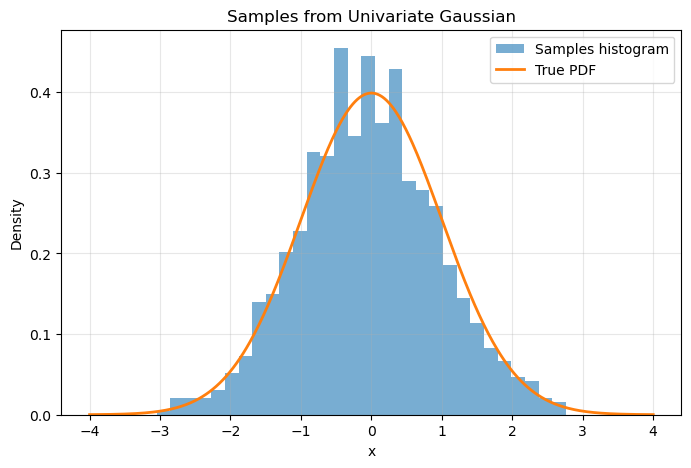

In [5]:
np.random.seed(0)

samples = np.random.normal(loc=0, scale=1, size=1000)

plt.figure(figsize=(8, 5))
plt.hist(samples, bins=30, density=True, alpha=0.6, label="Samples histogram")

x = np.linspace(-4, 4, 500)
plt.plot(x, gaussian_pdf_1d(x, mu=0, sigma=1), linewidth=2, label="True PDF")

plt.title("Samples from Univariate Gaussian")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

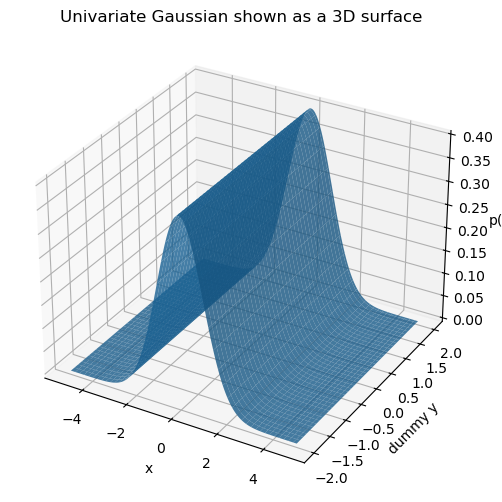

In [3]:
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-5, 5, 200)
y = np.linspace(-2, 2, 80)
X, Y = np.meshgrid(x, y)

Z = gaussian_pdf_1d(X, mu=0, sigma=1)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, alpha=0.8)

ax.set_title("Univariate Gaussian shown as a 3D surface")
ax.set_xlabel("x")
ax.set_ylabel("dummy y")
ax.set_zlabel("p(x)")
plt.show()

### Multivariate Gaussian Distribution

Generalizing from univariate Gaussian distribution to multivariate Gaussian distribution, assuming that the dimensions are independent of each other:

$$p(x_1, x_2, \dots, x_n) = \prod_{i=1}^{n} p(x_i) = \frac{1}{(2\pi)^{\frac{n}{2}} \sigma_1 \sigma_2 \dots \sigma_n} \exp\left( -\frac{1}{2} \left[ \frac{(x_1 - \mu_1)^2}{\sigma_1^2} + \dots + \frac{(x_n - \mu_n)^2}{\sigma_n^2} \right] \right)$$

Where $\mu_1, \mu_2, \dots$ and $\sigma_1, \sigma_2, \dots$ are the mean and variance of the 1st dimension, 2nd dimension, and so on. 

### The 2D Case is Most Common
For a two-dimensional variable:
$$\boldsymbol{x} = \begin{bmatrix} x_1 \\ x_2 \end{bmatrix}$$

Mean Vector:
$$\boldsymbol{\mu} = \begin{bmatrix} \mu_1 \\ \mu_2 \end{bmatrix}$$

Covariance Matrix:
$$\Sigma = \begin{bmatrix} \sigma_1^2 & \text{cov}(x_1, x_2) \\ \text{cov}(x_1, x_2) & \sigma_2^2 \end{bmatrix}$$

---

### Mathematical Formula for Multivariate Gaussian
$$p(\mathbf{x}) = \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp \left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \Sigma^{-1} (\mathbf{x} - \boldsymbol{\mu}) \right)$$

Where:
* $d$: Number of dimensions
* $|\Sigma|$: Determinant of the covariance matrix
* $\Sigma^{-1}$: Inverse of the covariance matrix

In [6]:
def gaussian_pdf_2d(X, Y, mu, Sigma):
    """
    二维高斯分布 PDF

    X, Y : meshgrid
    mu   : shape (2,)
    Sigma: shape (2,2)
    """
    pos = np.dstack((X, Y))   # shape: (n, m, 2)

    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)

    Sigma_inv = np.linalg.inv(Sigma)
    Sigma_det = np.linalg.det(Sigma)

    norm_const = 1.0 / (2 * np.pi * np.sqrt(Sigma_det))

    diff = pos - mu  # 每个网格点减去均值向量

    # 计算 (x-mu)^T Sigma^{-1} (x-mu)
    exponent = np.zeros(X.shape)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            d = diff[i, j]
            exponent[i, j] = -0.5 * (d.T @ Sigma_inv @ d)

    Z = norm_const * np.exp(exponent)
    return Z

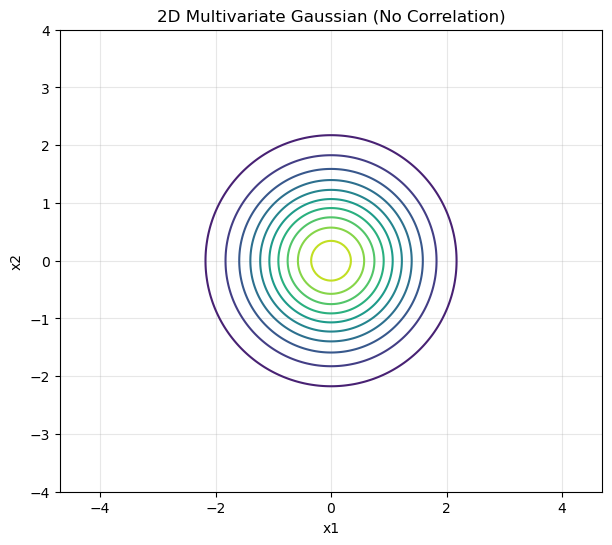

In [ ]:
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)

mu = np.array([0, 0])

# 分布中心在均值 (0,0)，等高线是圆形，x1与x2无相关性
Sigma = np.array([[1.0, 0.0],
                  [0.0, 1.0]])

Z = gaussian_pdf_2d(X, Y, mu, Sigma)

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=12)
plt.title("2D Multivariate Gaussian (No Correlation)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

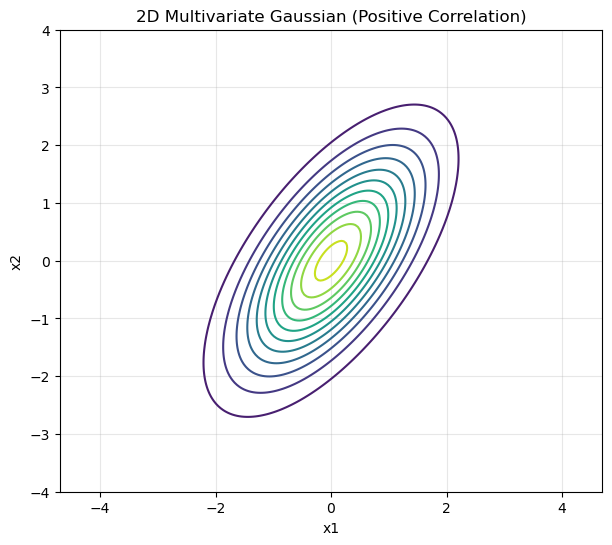

In [ ]:
mu = np.array([0, 0])

# 如果x1增大，x2往往也会增大
Sigma = np.array([[1.0, 0.8],
                  [0.8, 1.5]])

Z = gaussian_pdf_2d(X, Y, mu, Sigma)

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=12)
plt.title("2D Multivariate Gaussian (Positive Correlation)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

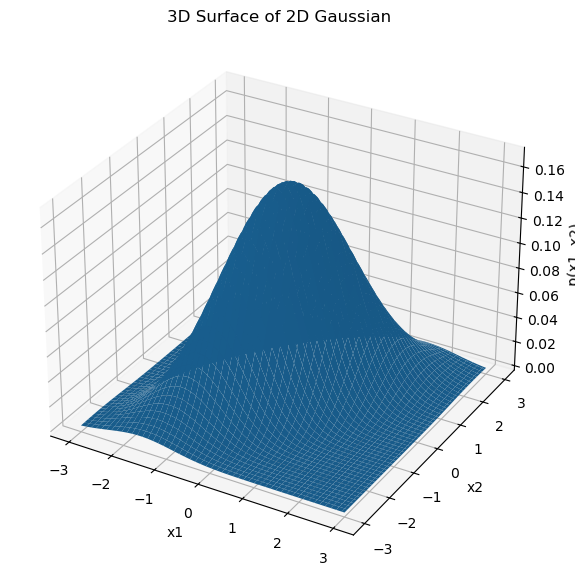

In [21]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

mu = np.array([0, 0])

Sigma = np.array([[1.0, 0.8],
                  [0.8, 1.5]])

Z = gaussian_pdf_2d(X, Y, mu, Sigma)

ax.plot_surface(X, Y, Z,shade=True)
ax.set_title("3D Surface of 2D Gaussian")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("p(x1, x2)")
plt.show()

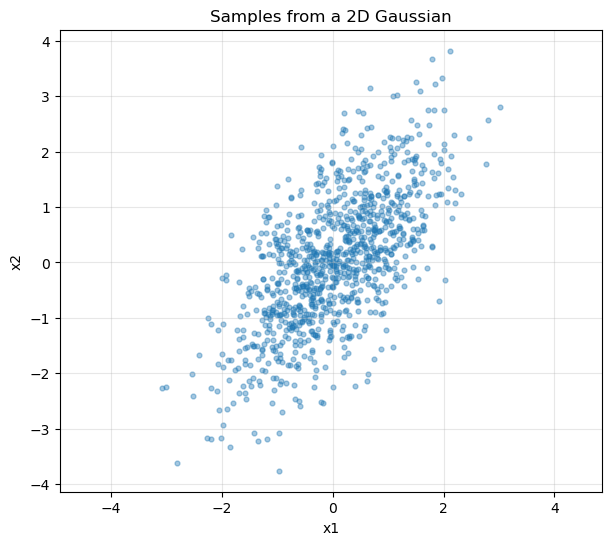

In [19]:
np.random.seed(0)

mu = np.array([0, 0])
Sigma = np.array([[1.0, 0.8],
                  [0.8, 1.5]])

samples = np.random.multivariate_normal(mu, Sigma, size=1000)

plt.figure(figsize=(7, 6))
plt.scatter(samples[:, 0], samples[:, 1], s=12, alpha=0.4)
plt.title("Samples from a 2D Gaussian")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

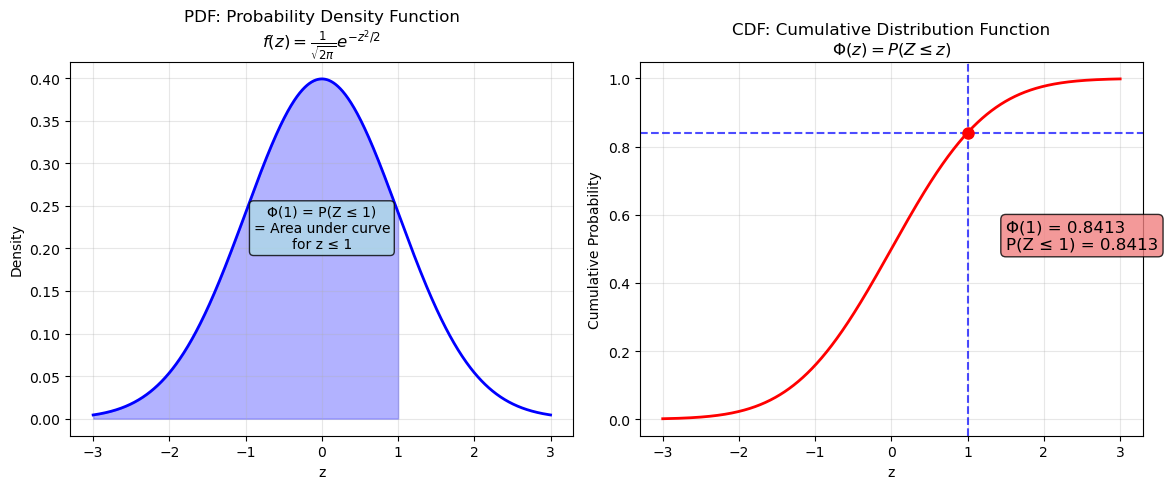

Common values for the standard normal CDF:
Φ(0) = 0.5000   (P(Z ≤ 0) = 0.5)
Φ(1) = 0.8413   (P(Z ≤ 1) ≈ 0.8413)
Φ(1.96) = 0.9750 (P(Z ≤ 1.96) ≈ 0.9750)
Φ(-1.96) = 0.0250 (P(Z ≤ -1.96) ≈ 0.0250)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Generate data
x = np.linspace(-3, 3, 1000)
pdf = norm.pdf(x, 0, 1)  # Probability Density Function PDF
cdf = norm.cdf(x, 0, 1)  # Cumulative Distribution Function CDF

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: PDF (Probability Density Function)
ax1.plot(x, pdf, 'b-', linewidth=2)
ax1.fill_between(x, pdf, where=(x <= 1), alpha=0.3, color='blue')
ax1.set_title('PDF: Probability Density Function\n$f(z) = \\frac{1}{\\sqrt{2\\pi}} e^{-z^2/2}$')
ax1.set_xlabel('z')
ax1.set_ylabel('Density')
ax1.grid(True, alpha=0.3)

# Mark the Φ(1) region
ax1.text(0, 0.2, 'Φ(1) = P(Z ≤ 1)\n= Area under curve\nfor z ≤ 1', 
         ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Right plot: CDF (Cumulative Distribution Function)
ax2.plot(x, cdf, 'r-', linewidth=2)
ax2.axhline(y=norm.cdf(1), color='blue', linestyle='--', alpha=0.7)
ax2.axvline(x=1, color='blue', linestyle='--', alpha=0.7)
ax2.plot(1, norm.cdf(1), 'ro', markersize=8)
ax2.set_title('CDF: Cumulative Distribution Function\n$\\Phi(z) = P(Z \\leq z)$')
ax2.set_xlabel('z')
ax2.set_ylabel('Cumulative Probability')
ax2.grid(True, alpha=0.3)

# Show Φ(1) value
ax2.text(1.5, 0.5, f'Φ(1) = {norm.cdf(1):.4f}\nP(Z ≤ 1) = {norm.cdf(1):.4f}', 
         fontsize=12, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.8))

plt.tight_layout()
plt.show()

# Print some common values
print("Common values for the standard normal CDF:")
print(f"Φ(0) = {norm.cdf(0):.4f}   (P(Z ≤ 0) = 0.5)")
print(f"Φ(1) = {norm.cdf(1):.4f}   (P(Z ≤ 1) ≈ 0.8413)")
print(f"Φ(1.96) = {norm.cdf(1.96):.4f} (P(Z ≤ 1.96) ≈ 0.9750)")
print(f"Φ(-1.96) = {norm.cdf(-1.96):.4f} (P(Z ≤ -1.96) ≈ 0.0250)")